# Frequency-Domain Filtering

Frequency-domain filtering modifies a signal by selectively attenuating or preserving specific frequency components. Rather than operating directly in the time domain, the signal is first transformed into the frequency domain using the Fast Fourier Transform (FFT), filtered by a prescribed frequency response, and then reconstructed using the inverse FFT. Frequency-domain filtering is widely used in signal processing, communications, instrumentation, and computational physics to remove unwanted noise or isolate frequency bands of interest.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Low-Pass Filter

An RC low-pass filter is applied in the frequency domain using the transfer function

$$
H(f)=\frac{1}{1+i2\pi fRC},
$$

where $R$ is the resistance, $C$ is the capacitance, and

$$
f_c=\frac{1}{2\pi RC}
$$

is the cutoff frequency. The filter preserves low-frequency components while progressively attenuating higher frequencies.

In [3]:
fs, T = 2000, 2
f0, t0, sigma = 10, 1, 0.2
R, C = 330, 47e-6
fc = 1 / (2*np.pi*R*C)

## Input Signal

The input signal is a Gaussian-modulated sinusoid,

$$
x(t)=\exp\left(-\frac{(t-t_0)^2}{2\sigma^2}\right)\sin(2\pi f_0t),
$$

where $f_0$ is the carrier frequency, $t_0$ is the center of the Gaussian envelope, and $\sigma$ determines the pulse width.

In [4]:
t = np.linspace(0, T, fs*T)
x = np.exp(-(t - t0)**2 / (2*sigma**2)) * np.sin(2*np.pi*f0*t)

## Frequency-Domain Filtering

After computing the Fourier transform of the input signal, the filtered spectrum is obtained by

$$
X_{\mathrm{filtered}}(f)=H(f)X(f),
$$

where $X(f)$ is the Fourier transform of the original signal. The filtered time-domain signal is then reconstructed using the inverse Fast Fourier Transform (IFFT). The following code performs the filtering using `scipy.fft`.


In [5]:
X = fft(x)
freqs = fftfreq(len(x), 1/fs)
omega = 2*np.pi*freqs
H = 1 / (1 + 1j * omega * R * C)

In [6]:
X_filtered = X * H
x_filtered = ifft(X_filtered)

The filtered signal is compared with the original signal in the time domain to illustrate the effect of removing high-frequency components.

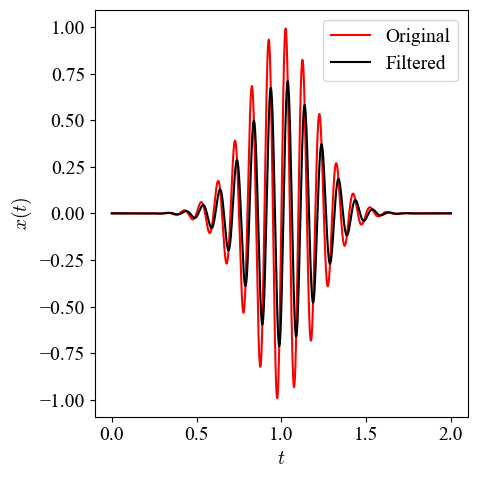

In [7]:
plt.figure(figsize=(5, 5))
plt.plot(t, x, color="r", label="Original")
plt.plot(t, x_filtered.real, color="k", label="Filtered")
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.legend()
plt.tight_layout()
plt.show()

## Filter Response

The magnitude response $|H(f)|$, shows how the filter attenuates different frequency components. Frequencies below the cutoff frequency are largely preserved, whereas higher frequencies are increasingly suppressed.

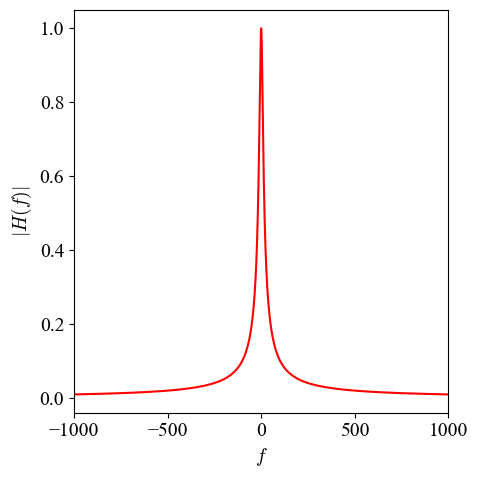

In [8]:
plt.figure(figsize=(5, 5))
plt.plot(fftshift(freqs), np.abs(fftshift(H)), color="r")
plt.xlim(-1000, 1000)
plt.xlabel(r"$f$")
plt.ylabel(r"$|H(f)|$")
plt.tight_layout()
plt.show()

## Spectral Comparison

The magnitude spectra of the original and filtered signals are compared to visualize the attenuation introduced by the low-pass filter in the frequency domain.

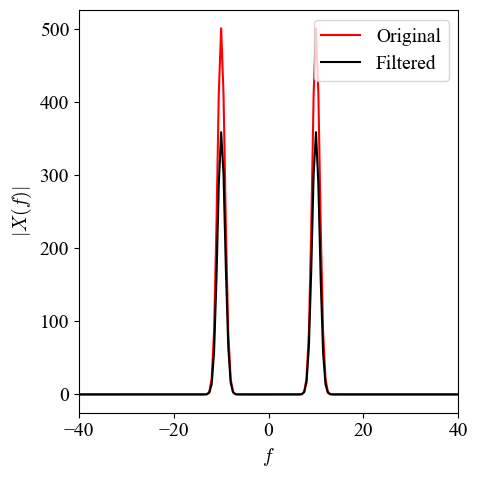

In [9]:
plt.figure(figsize=(5, 5))
plt.plot(fftshift(freqs), fftshift(np.abs(X)), color="r", label="Original")
plt.plot(fftshift(freqs), fftshift(np.abs(X_filtered)), color="k", label="Filtered")
plt.xlim(-40, 40)
plt.xlabel(r"$f$")
plt.ylabel(r"$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

* Frequency-domain filtering modifies a signal by operating on its frequency components.
* A low-pass filter preserves low frequencies while attenuating high-frequency components.
* Filtering is performed by multiplying the signal spectrum by the filter transfer function.
* The filtered time-domain signal is recovered using the inverse FFT.